# Analisis Data Penumpang Titanic: Dari Penanganan Missing Value hingga Penentuan Fitur Paling Berpengaruh
Aggota Kelompok :
1.   Elkana Juanro Manullang		122140168
2.   Rachel Olivia Manullang		122140181
3.   Martua Kevin A.M.H.Lubis	  122140119

Dataset : pembelian.csv dan stok.csv

# **Pendahuluan**
Laporan ini menyajikan analisis komprehensif terhadap dataset penjualan dan stok produk dengan tujuan utama untuk mengidentifikasi produk-produk yang paling berpengaruh dalam inventaris. Analisis ini mencakup dua tahap utama: pertama, pemrosesan dan pemahaman data dari kedua dataset, dan kedua, analisis mendalam untuk mengukur dan memeringkat produk berdasarkan berbagai metrik seperti jumlah pembelian dan ketersediaan stok.

# **Masalah**
Analisis awal pada dataset menunjukkan adanya informasi yang tersebar di dua file terpisah, yaitu data pembelian dan data stok. Masalah utama adalah bagaimana cara menggabungkan dan menganalisis data ini secara efektif untuk mendapatkan wawasan yang berguna mengenai performa produk dan manajemen inventaris.

#**Tahap 1: Persiapan Lingkungan Kerja dan Eksplorasi Data Awal**
Analisis ini menggunakan dua dataset:

pembelian.csv: Berisi data transaksi pembelian produk, termasuk tanggal, nomor transaksi, kuantitas masuk (QTY.MSK), dan nilai masuk (NILAI MSK).

stok.csv: Berisi data stok produk, termasuk kode produk, nama produk, lokasi, dan kuantitas stok (QTY.STOK).

Kode di bawah ini akan memuat library yang dibutuhkan, memuat dataset train.csv
1. Setup Library: Kode pertama mengimpor library yang akan kita gunakan. Pandas adalah "meja kerja" utama kita untuk mengelola data dalam bentuk tabel (DataFrame). NumPy menyediakan dukungan untuk operasi matematika yang efisien. Matplotlib dan Seaborn adalah "alat lukis" kita untuk membuat berbagai jenis grafik dan visualisasi data.
2. Load Data: Selanjutnya, kita memuat "bahan utama" kita, yaitu dataset train.csv, ke dalam sebuah DataFrame bernama df.
3. Eksplorasi Awal: Seperti koki yang mencicipi bahannya, kita melakukan pemeriksaan awal. .head() digunakan untuk "mengintip" 5 baris pertama data. .info() memberikan "kartu identitas" dataset, merangkum tipe data setiap kolom dan jumlah entri yang tidak kosong. .shape memberi tahu kita dimensi data secara keseluruhan.

In [1]:
# =============================================================================
# TAHAP 1: PERSIAPAN
# =============================================================================
print("=========================================")
print("TAHAP 1: PERSIAPAN")
print("=========================================\n")

# 1.1 Setup Library
# Mengimpor library yang dibutuhkan untuk analisis data dan visualisasi.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("1.1 Library berhasil di-import.")

# 1.2 Load Data
# Membaca file 'stok.csv' ke dalam sebuah DataFrame pandas.
# Pastikan file 'stok.csv' sudah di-upload ke environment Anda.
try:
    df = pd.read_csv('stok.csv', delimiter=';')
    # Membersihkan nama kolom dari karakter yang tidak diinginkan
    df.columns = df.columns.str.replace('"', '').str.strip()
    print("1.2 Dataset 'stok.csv' berhasil di-load.\n")
except FileNotFoundError:
    print("Error: File 'stok.csv' tidak ditemukan. Mohon upload file tersebut terlebih dahulu.")
    # Hentikan eksekusi jika file tidak ada
    exit()


# 1.3 Eksplorasi Awal
print("1.3 Eksplorasi Awal Data:")
print("--------------------------")
# Menampilkan 5 baris pertama dari data untuk mendapatkan gambaran awal.
print("a. Preview 5 baris pertama data:")
print(df.head())
print("\n")

# Menampilkan informasi ringkas tentang DataFrame, termasuk tipe data dan non-null count.
print("b. Informasi struktur data (info):")
df.info()
print("\n")

# Menampilkan jumlah baris dan kolom.
print(f"c. Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
print("\n")

TAHAP 1: PERSIAPAN

1.1 Library berhasil di-import.
1.2 Dataset 'stok.csv' berhasil di-load.

1.3 Eksplorasi Awal Data:
--------------------------
a. Preview 5 baris pertama data:
      KODE         NAMA PRODUK LOKASI  QTY.STOK     UNIT
0  A000001          ANATON TAB   ETL1      12.0  STRIP\n
1   A00001       ACTIVED HIJAU  ETL3A       2.0    BTL\n
2  A000012  APIALYS SYR 100 ML  ETL3A       2.0    BTL\n
3  A000014     ALKOHOL 1000 ML  ETL3B       7.0    BTL\n
4  A000016     ALLOPURINOL 300   RAK2      40.0  STRIP\n


b. Informasi struktur data (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1521 entries, 0 to 1520
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   KODE         1520 non-null   object 
 1   NAMA PRODUK  1518 non-null   object 
 2   LOKASI       1516 non-null   object 
 3   QTY.STOK     1518 non-null   float64
 4   UNIT         1518 non-null   object 
dtypes: float64(1), object(4)
memory usag

#**Tahap 2 : Deteksi Kuantitatif Missing Value**
Setelah mengenal data secara umum, kita fokus pada masalah utama: data yang hilang. Penting untuk mengukur masalah ini secara kuantitatif. Kode di bawah ini melakukan tiga hal:
1. Menghitung Jumlah: .isnull().sum() adalah perintah untuk menghitung semua sel kosong di setiap kolom. Ini memberi kita skala absolut dari masalah.
2. Menghitung Persentase: Angka absolut tidak selalu menceritakan keseluruhan cerita. Dengan menghitung persentase, kita memahami tingkat keparahan masalah relatif terhadap ukuran kolom.
3. Menghitung Total: Menjumlahkan semua nilai yang hilang memberi kita gambaran keseluruhan tentang "kesehatan" dataset kita.

In [2]:
# =============================================================================
# TAHAP 2: IDENTIFIKASI MISSING VALUE
# =============================================================================
print("=========================================")
print("TAHAP 2: IDENTIFIKASI MISSING VALUE")
print("=========================================\n")

# 2.1 Deteksi Missing Value
print("2.1 Deteksi Kuantitatif Missing Value:")
print("---------------------------------------")
# Menghitung jumlah missing value untuk setiap kolom.
missing_count = df.isnull().sum()
print("a. Jumlah missing value per kolom:")
# Tampilkan semua kolom, bahkan yang tidak punya missing value, untuk konfirmasi
print(missing_count)
print("\n")

# Menghitung persentase missing value.
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("b. Persentase missing value per kolom (%):")
print(missing_percentage[missing_percentage > 0].round(2)) # Hanya tampilkan jika > 0
print("\n")

# Menghitung total missing value di seluruh dataset.
total_missing = df.isnull().sum().sum()
print(f"c. Total sel yang kosong (missing) di seluruh data: {total_missing} sel.\n")

TAHAP 2: IDENTIFIKASI MISSING VALUE

2.1 Deteksi Kuantitatif Missing Value:
---------------------------------------
a. Jumlah missing value per kolom:
KODE           1
NAMA PRODUK    3
LOKASI         5
QTY.STOK       3
UNIT           3
dtype: int64


b. Persentase missing value per kolom (%):
KODE           0.07
NAMA PRODUK    0.20
LOKASI         0.33
QTY.STOK       0.20
UNIT           0.20
dtype: float64


c. Total sel yang kosong (missing) di seluruh data: 15 sel.



#**Tahap 3 : Visualisasi Pola Missing Value**
Untuk pemahaman yang lebih baik, pola data yang hilang divisualisasikan. Kode ini akan membuat dua jenis plot:
1. Bar Chart: Kode ini membuat diagram batang yang secara visual membandingkan jumlah data hilang antar kolom.
2. Heatmap: Heatmap memberikan pandangan "mata burung" ke seluruh dataset. Garis kuning horizontal menunjukkan data yang hilang. Visual ini sangat efektif untuk melihat pola: apakah data hilang secara acak atau terkonsentrasi di baris-baris tertentu?

Total missing value di seluruh dataset: 15
Jumlah per kolom:
KODE           1
NAMA PRODUK    3
LOKASI         5
QTY.STOK       3
UNIT           3
dtype: int64


2. Visualisasi Pola Missing Value:
-----------------------------------
a. Menampilkan Bar Chart jumlah missing value...


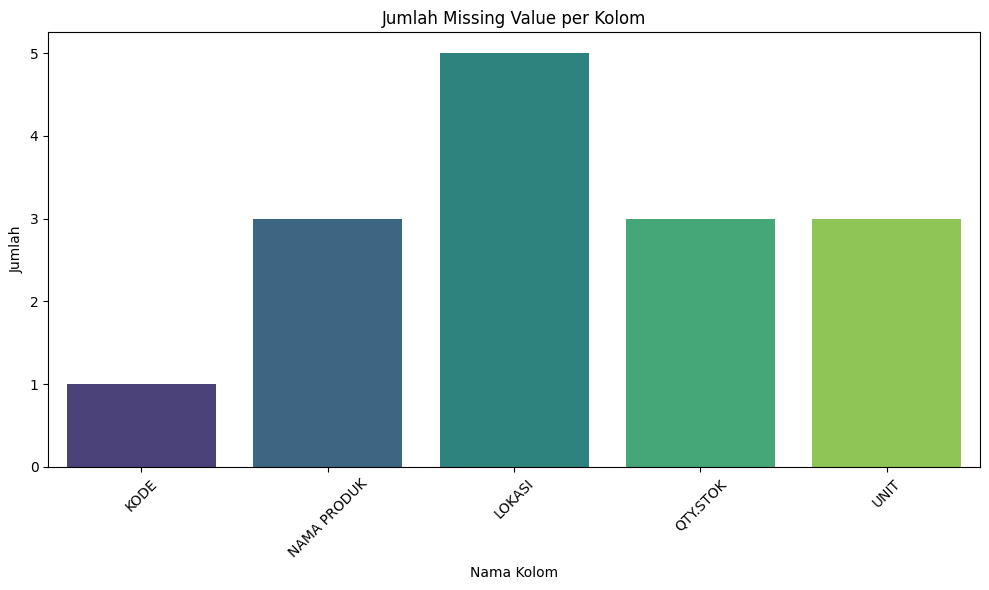

   Bar chart telah ditampilkan.

b. Menampilkan Heatmap dengan batasan agar pola terlihat...
   (Dari total 1521 baris, heatmap ini hanya menampilkan 5 baris yang bermasalah)
   Heatmap pola missing value telah ditampilkan. Garis kuning menandakan data yang hilang.



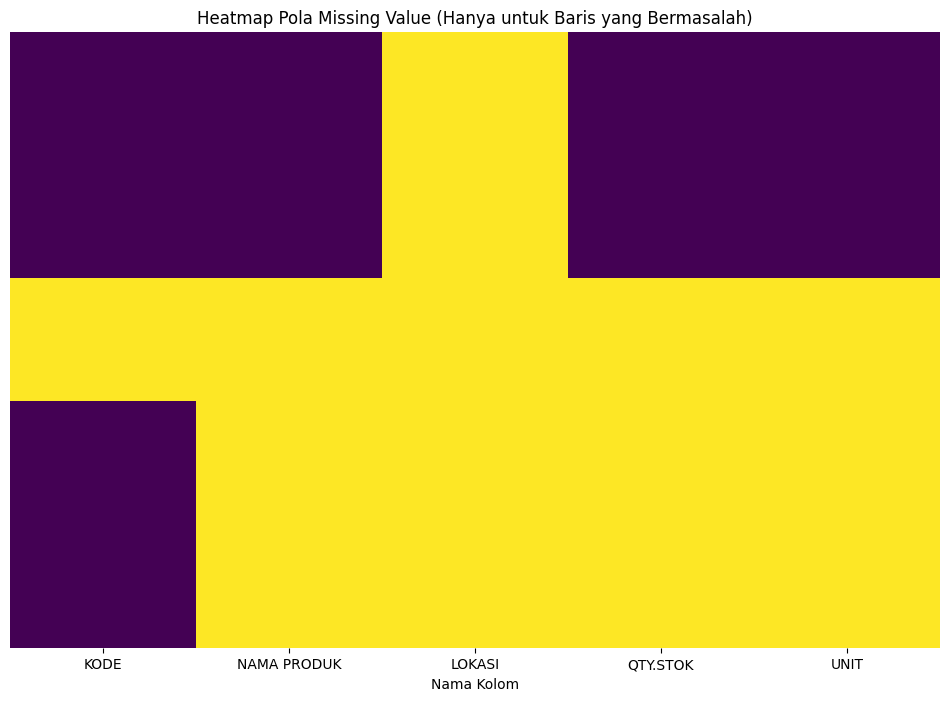

In [3]:
# 2.2 Visualisasi Pola Missing Value
missing_count = df.isnull().sum()
total_missing = missing_count.sum()

if total_missing > 0:
    print(f"Total missing value di seluruh dataset: {total_missing}")
    print("Jumlah per kolom:")
    print(missing_count[missing_count > 0])
else:
    print("Tidak ditemukan missing value dalam dataset.")

print("\n" + "="*50 + "\n")


#-----------------------------------------------------------------------
# Bagian 2: Visualisasi Pola Missing Value
#-----------------------------------------------------------------------
print("2. Visualisasi Pola Missing Value:")
print("-----------------------------------")

# Cek dulu apakah ada missing value sebelum membuat plot
if total_missing > 0:
    # a. Membuat bar chart untuk jumlah missing value.
    print("a. Menampilkan Bar Chart jumlah missing value...")
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=missing_count[missing_count > 0].index,
        y=missing_count[missing_count > 0].values,
        palette='viridis',
        hue=missing_count[missing_count > 0].index, # Ditambahkan untuk menghilangkan warning
        legend=False
    )
    plt.title('Jumlah Missing Value per Kolom')
    plt.ylabel('Jumlah')
    plt.xlabel('Nama Kolom')
    plt.xticks(rotation=45) # Memutar label jika namanya panjang
    plt.tight_layout()
    plt.show()
    print("   Bar chart telah ditampilkan.\n")

    # b. Membuat heatmap HANYA untuk baris yang memiliki missing value.
    # Ini adalah solusi agar pola terlihat jelas.
    print("b. Menampilkan Heatmap dengan batasan agar pola terlihat...")

    # Filter DataFrame untuk hanya menyertakan baris dengan setidaknya satu nilai null
    df_with_missing = df[df.isnull().any(axis=1)]

    print(f"   (Dari total {len(df)} baris, heatmap ini hanya menampilkan {len(df_with_missing)} baris yang bermasalah)")

    plt.figure(figsize=(12, 8))
    sns.heatmap(df_with_missing.isnull(), cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Heatmap Pola Missing Value (Hanya untuk Baris yang Bermasalah)')
    plt.xlabel('Nama Kolom')
    print("   Heatmap pola missing value telah ditampilkan. Garis kuning menandakan data yang hilang.\n")
    plt.show()

else:
    print("a. Tidak ada visualisasi yang dibuat karena tidak ada missing value untuk ditampilkan.\n")

#**Tahap 4 : Analisis Detail Pola Missing Value**
Setelah melihat gambaran besar, kita perlu menggali lebih dalam. Kode ini membantu kita menjawab, "Berapa banyak penumpang yang datanya tidak lengkap?" dengan menghitung jumlah baris yang memiliki setidaknya satu nilai kosong. Kita juga menampilkan lima contoh penumpang dengan data tidak lengkap untuk melihat seperti apa data tersebut secara konkret. Bagian ini diakhiri dengan ringkasan analisis pola yang menyimpulkan observasi dari tahap kuantitatif dan visual.

In [4]:
# 2.3 Analisis Detail
print("2.3 Analisis Detail:")
print("--------------------")
# Mengidentifikasi baris-baris yang memiliki setidaknya satu missing value.
rows_with_missing = df[df.isnull().any(axis=1)]

if not rows_with_missing.empty:
    print(f"a. Ditemukan {len(rows_with_missing)} baris yang mengandung setidaknya satu missing value.")
    print("   Contoh 5 baris dengan missing value:")
    print(rows_with_missing.head())
    print("\n")
else:
    print(f"a. Tidak ditemukan baris yang mengandung missing value.\n")


print("b. Analisis Pola:")
if total_missing > 0:
    print("- Analisis pola akan dilakukan pada kolom yang memiliki missing value.")
else:
    print("- Dataset 'stok.csv' bersih dan tidak menunjukkan adanya pola data yang hilang.\n")

2.3 Analisis Detail:
--------------------
a. Ditemukan 5 baris yang mengandung setidaknya satu missing value.
   Contoh 5 baris dengan missing value:
      KODE     NAMA PRODUK LOKASI  QTY.STOK    UNIT
553   G001  CEK GULA DARAH    NaN       7.0  KALI\n
1189  P001          PERMEN    NaN      70.0   set\n
1518   NaN             NaN    NaN       NaN     NaN
1519    \n             NaN    NaN       NaN     NaN
1520    \n             NaN    NaN       NaN     NaN


b. Analisis Pola:
- Analisis pola akan dilakukan pada kolom yang memiliki missing value.
